# MP1 — Relaxed 3×3 CDW structure of NbSe₂

Companion to Mini-project 1, Stage 2. Builds the before/after picture of the
3×3 supercell: the soft mode at q$_{CDW}$=(1/3,0) was frozen in (3Q, triangular)
and relaxed. Left: Nb displacements (×6). Right: the Nb–Nb bond network, which
makes the **triangular Nb clusters** of the CDW obvious. Reads the relaxed
coordinates from `ref/nbse2.3x3.relax.out`.

Nb |u| (A): [0.033 0.037 0.037 0.05  0.055 0.055 0.087 0.087 0.091] | mean 0.059 max 0.091
Nb-Nb NN: undistorted 3.473 A -> clusters 3.381 A, between 3.626 A


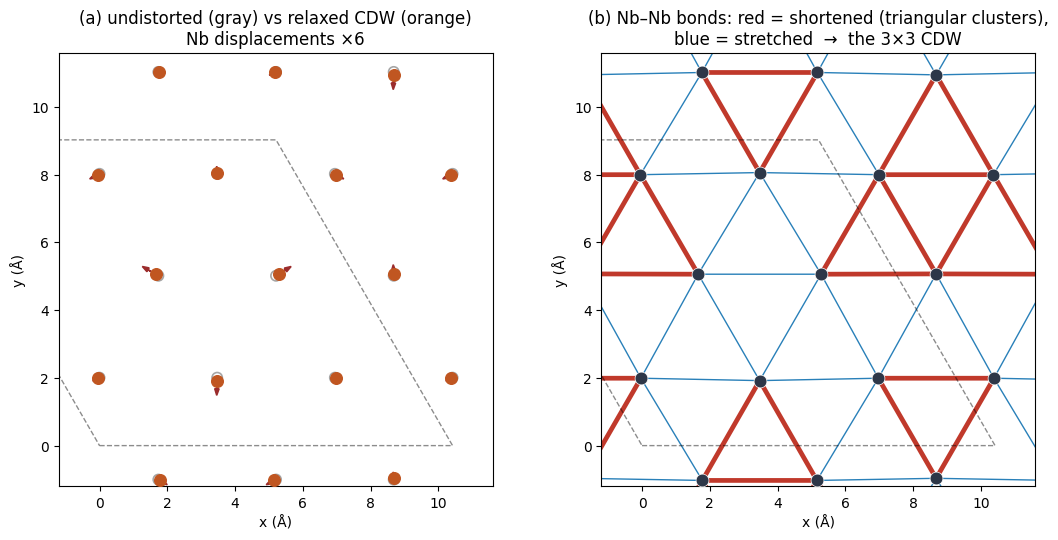

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base = Path('../code/advanced/04-nbse2-cdw')

def read_relax_final(fn):
    blk = open(fn).read().split('Begin final coordinates')[1].split('End final coordinates')[0]
    blk = blk.split('ATOMIC_POSITIONS')[1].splitlines()[1:]
    sp, xyz = [], []
    for l in blk:
        t = l.split()
        if len(t) >= 4 and t[0] in ('Nb', 'Se'):
            sp.append(t[0]); xyz.append([float(t[1]), float(t[2]), float(t[3])])
    return sp, np.array(xyz)

def read_in_pos(fn):
    blk = open(fn).read().split('ATOMIC_POSITIONS angstrom')[1].split('K_POINTS')[0]
    sp, xyz = [], []
    for l in blk.strip().splitlines():
        t = l.split()
        if t[0] in ('Nb', 'Se'):
            sp.append(t[0]); xyz.append([float(x) for x in t[1:4]])
    return sp, np.array(xyz)

sp_d, xd = read_relax_final(base/'ref/nbse2.3x3.relax.out')
sp_u, xu = read_in_pos(base/'inputs/nbse2.3x3.scf.in')

a0 = 3.472867181
A1 = 3*np.array([a0, 0.]); A2 = 3*np.array([-a0/2, a0*np.sqrt(3)/2])
M = np.array([A1, A2]).T
def mic(d):
    f = np.linalg.solve(M, d); f -= np.round(f); return M @ f

nbm = [i for i, s in enumerate(sp_d) if s == 'Nb']
Pu = xu[nbm][:, :2]; Pd = xd[nbm][:, :2]
du = np.array([mic(d) for d in (Pd - Pu)])
print("Nb |u| (A):", np.round(np.sort(np.linalg.norm(du, axis=1)), 3),
      "| mean %.3f max %.3f" % (np.linalg.norm(du,axis=1).mean(), np.linalg.norm(du,axis=1).max()))

# Nb-Nb nearest-neighbour bonds (with periodic images)
bonds = []
for i in range(9):
    for j in range(9):
        if i < j:
            d = mic(Pd[j] - Pd[i]); L = np.linalg.norm(d)
            if L < 1.25*a0: bonds.append((i, d, L))
Ls = np.array([b[2] for b in bonds])
print("Nb-Nb NN: undistorted %.3f A -> clusters %.3f A, between %.3f A" % (a0, Ls.min(), Ls.max()))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 5.3))

# (a) before/after with displacement arrows (x6)
for s1 in (-1,0,1):
  for s2 in (-1,0,1):
    sh = s1*A1 + s2*A2
    axL.scatter(*(Pu+sh).T, s=55, facecolors='none', edgecolors='0.65', lw=1.2, zorder=1)
    axL.scatter(*(Pd+sh).T, s=70, c='#c05621', zorder=3)
    for p0, d in zip(Pu+sh, du*6):
        if np.linalg.norm(d) > 5e-3:
            axL.arrow(p0[0],p0[1],d[0],d[1], head_width=0.13, color='#9b2c2c', lw=1.1,
                      length_includes_head=True, zorder=2)
axL.set_title('(a) undistorted (gray) vs relaxed CDW (orange)\nNb displacements ×6')

# (b) Nb-Nb bond network coloured by length
for s1 in (-1,0,1):
  for s2 in (-1,0,1):
    sh = s1*A1 + s2*A2
    for (i, d, L) in bonds:
        p = Pd[i] + sh
        if L < a0-0.01: col, lw = '#c0392b', 3.4      # shortened: cluster
        elif L > a0+0.01: col, lw = '#2980b9', 1.0     # stretched
        else: col, lw = '0.8', 0.6
        axL2 = axR
        axR.plot([p[0],p[0]+d[0]],[p[1],p[1]+d[1]], color=col, lw=lw, zorder=1, solid_capstyle='round')
    axR.scatter(*(Pd+sh).T, s=85, c='#2d3748', zorder=3, edgecolors='w', lw=0.5)
axR.set_title('(b) Nb–Nb bonds: red = shortened (triangular clusters),\nblue = stretched  →  the 3×3 CDW')

for ax in (axL, axR):
    corners = np.array([[0,0], A1, A1+A2, A2, [0,0]])
    ax.plot(corners[:,0], corners[:,1], 'k--', lw=1, alpha=0.45)
    ax.set_aspect('equal'); ax.set_xlim(-1.2, 11.6); ax.set_ylim(-1.2, 11.6)
    ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)')
fig.tight_layout()
fig.savefig('../static/img/MP1-nbse2-cdw-structure.png', dpi=120)
plt.show()

**The textbook NbSe₂ CDW.** The relaxed Nb atoms move by only **~0.06–0.09 Å**
(a few % of the 3.47 Å spacing) — but that small displacement groups them into
**triangular clusters**: nearest-neighbour Nb–Nb bonds *shorten* from 3.47 Å to
**3.38 Å** inside a cluster (red) and *stretch* to **3.63 Å** between clusters
(blue), tiling the 3×3 superlattice. This is exactly the 3×3 triangular CDW seen
in STM. The distortion is small because NbSe₂ is a **weak CDW** (condensation
energy only ~3 meV/f.u.); the charge modulation it produces is what STM images
with high contrast.